# 1. Canonical mini-ELF

The simplest pipeline: a 15-segment ring of circular sub-apertures, no atmosphere, no coronagraph. Loaded from the bundled `elf_15seg` preset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from telescope_sim import TelescopeSim

sim = TelescopeSim.from_preset("elf_15seg")
print("correctors:", list(sim.correctors))
print("focal planes:", list(sim.focal_planes))


correctors: ['segments']
focal planes: ['filter1', 'filter2']


Sample at rest (no actuators applied) and inspect the result. The output `images['psf']` is channels-last over filters; the preset has two filters at 500 nm and 1 µm.

psf shape: (128, 128, 2) strehls: {'filter1': 1.0, 'filter2': 1.0}


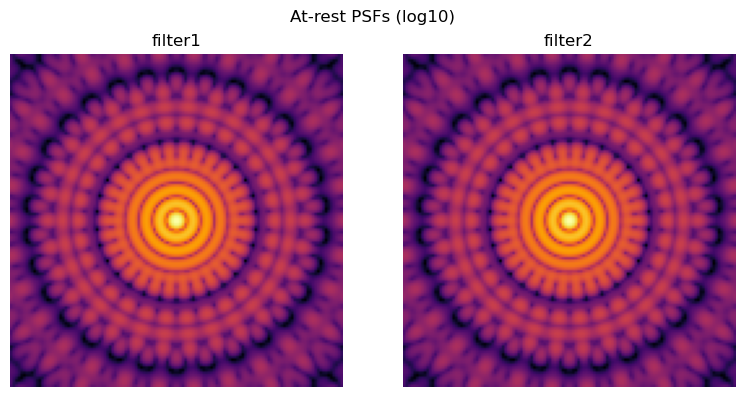

In [2]:
out = sim.sample(meas_strehl=True)
psf = out["images"]["psf"]
print("psf shape:", psf.shape, "strehls:", out["strehls"])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (filt, idx) in zip(axes, list(sim.focal_planes.items())):
    im = ax.imshow(np.log10(psf[..., 0] + 1e-8), cmap="inferno")
    ax.set_title(filt)
    ax.set_axis_off()
fig.suptitle("At-rest PSFs (log10)")
plt.tight_layout()
plt.show()


Apply random per-segment piston/tip/tilt errors and resample.

strehls with errors: {'filter1': 0.2463175822104899, 'filter2': 0.4187090425146988}


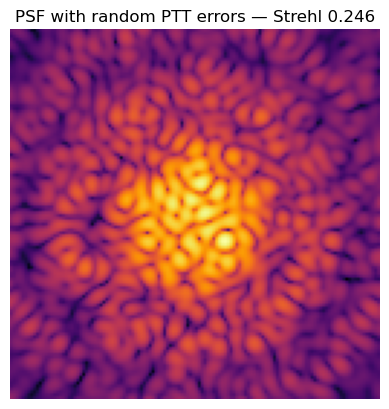

In [3]:
rng = np.random.default_rng(0)
ptt = rng.normal(scale=0.1, size=(15, 3))
out = sim.sample(actuations={"segments": ptt}, meas_strehl=True)
print("strehls with errors:", out["strehls"])

plt.imshow(np.log10(out["images"]["psf"][..., 0] + 1e-8), cmap="inferno")
plt.title(f"PSF with random PTT errors — Strehl {out['strehls']['filter1']:.3f}")
plt.axis("off")
plt.show()
